In [52]:
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

In [53]:
x, y = make_blobs(n_samples=500, centers=3, cluster_std=0.4, random_state=0)

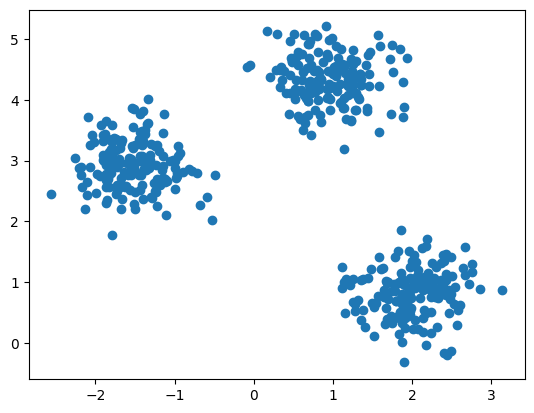

In [54]:
plt.scatter(x[:, 0], x[:, 1])

In [55]:
db = DBSCAN(eps=0.3, min_samples=10).fit(x)
# In the code snippet provided, `(x)` is likely representing the input data that is being used to fit the DBSCAN clustering algorithm. The `fit()` method is being called on the DBSCAN object with the input data `x`, which suggests that `x` contains the features or data points that will be clustered using the DBSCAN algorithm with an epsilon value of 0.3 and a minimum number of samples set to 10.

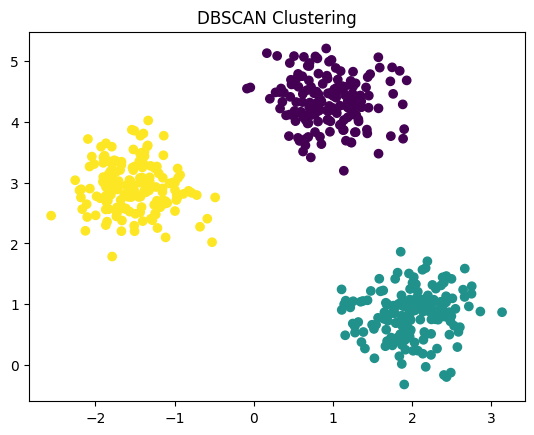

In [56]:
plt.scatter(x[:, 0], x[:, 1], c=y)  # means color by cluster labels
plt.title("DBSCAN Clustering")
plt.show()

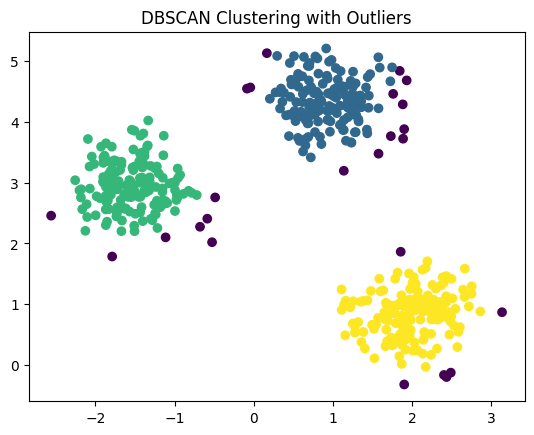

In [57]:
plt.scatter(
    x[:, 0], x[:, 1], c=db.labels_
)  # means color by cluster labels assigned by DBSCAN
plt.title("DBSCAN Clustering with Outliers")
plt.show()

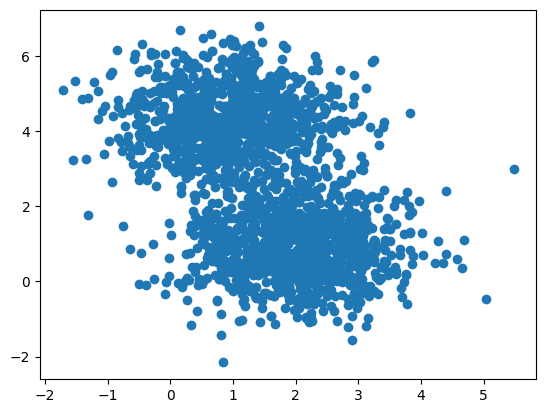

In [ ]:
x, y = make_blobs(n_samples=2000, centers=2, cluster_std=0.9, random_state=0)
plt.scatter(x[:, 0], x[:, 1])  # means 

In [59]:
ee = EllipticEnvelope(contamination=0.1)
ee.fit(x)

,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, the support of robust location and covariance estimatesis computed, and a covariance estimate is recomputed from it,without centering the data.Useful to work with data whose mean is significantly equal tozero but is not exactly zero.If False, the robust location and covariance are directly computedwith the FastMCD algorithm without additional treatment.",False
,"support_fraction support_fraction: float, default=NoneThe proportion of points to be included in the support of the rawMCD estimate. If None, the minimum value of support_fraction willbe used within the algorithm: `(n_samples + n_features + 1) / 2 * n_samples`.Range is (0, 1).",None
,"contamination contamination: float, default=0.1The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Range is (0, 0.5].",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the pseudo random number generator for shufflingthe data. Pass an int for reproducible results across multiple functioncalls. See :term:`Glossary `.",None


In [60]:
prediction = ee.predict(x)

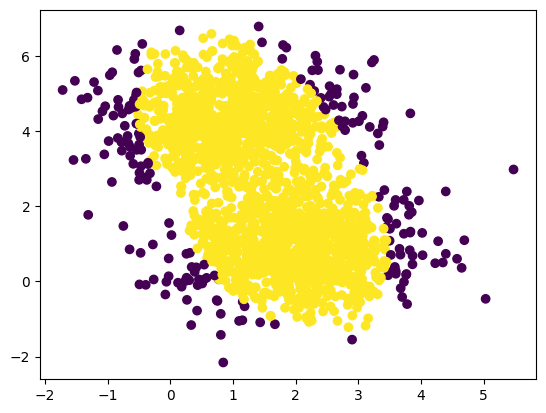

In [61]:
plt.scatter(x[:, 0], x[:, 1], c=prediction)

In [62]:
iso = IsolationForest()

In [63]:
iso.fit(x)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [64]:
pred = iso.predict(x)

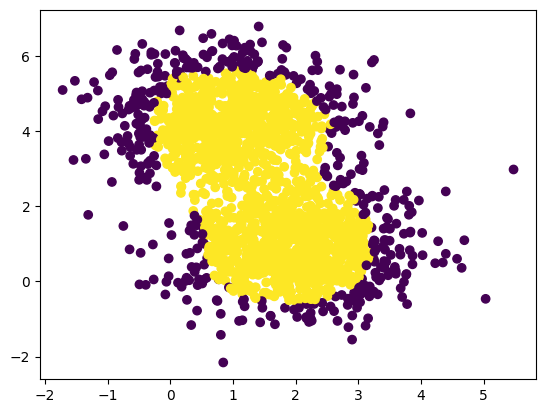

In [65]:
plt.scatter(x[:, 0], x[:, 1], c=pred)

In [66]:
from sklearn.neighbors import LocalOutlierFactor

In [67]:
clf = LocalOutlierFactor(n_neighbors=3)
clf.fit(x)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",3
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",False
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [68]:
pred = clf.fit_predict(x)

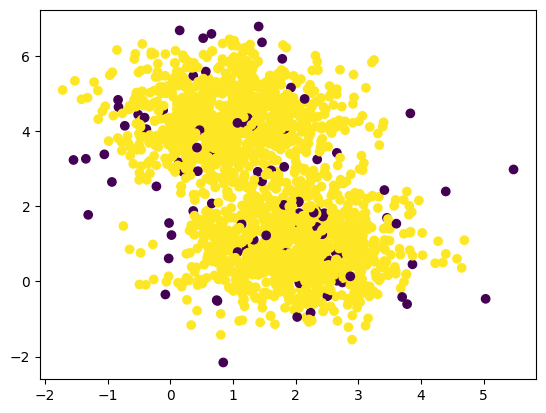

In [69]:
plt.scatter(x[:, 0], x[:, 1], c=pred)

In [70]:
x = np.array([[1, 5], [1, 6], [1, 7], [2, 5], [2, 6], [6, 5], [9, 1]])

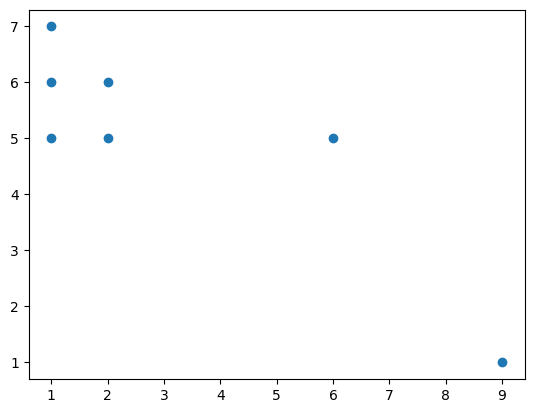

In [71]:
plt.scatter(x[:, 0], x[:, 1])
plt.show()

In [72]:
X = x[:, 0]
y = x[:, 1]

X = X.reshape(-1, 1)
clf = LocalOutlierFactor(n_neighbors=3)
clf.fit(X)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",3
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",False
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


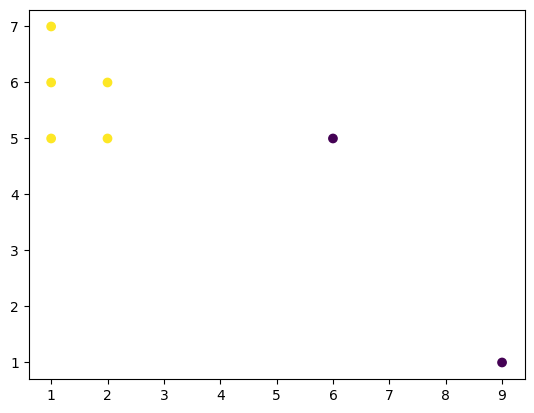

In [73]:
pred = clf.fit_predict(X)
plt.scatter(X, y, c=pred)